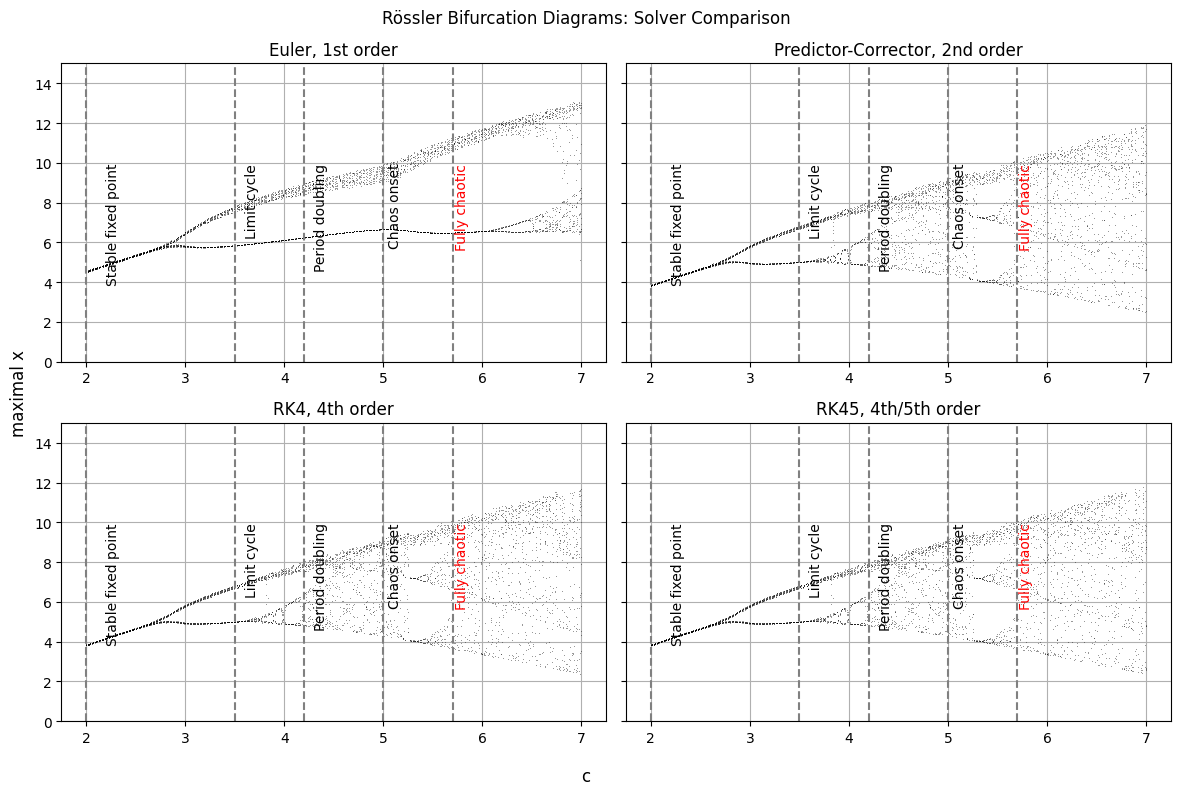

CPU times: user 2min 30s, sys: 333 ms, total: 2min 30s
Wall time: 2min 33s


In [ ]:
%%time

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Rossler comparison

# parameters
a = 0.2
b = 0.2

def rossler(X, c):
    x,y,z = X
    return np.array([
        -y - z,
        x + a*y,
        b + z*(x - c)
    ])

# time parameters
dt = 0.05
tmax = 150
steps = int(tmax/dt)

c_vals = np.linspace(2,7,350)

#1) Euler- 1st order
def euler_solver(X0,c):
    X = np.zeros((steps,3))
    X[0] = X0
    for i in range(steps-1):
        X[i+1] = X[i] + dt*rossler(X[i],c)
    return X

#2) Predictor-Corrector- 2nd order
def heun_solver(X0,c):
    X = np.zeros((steps,3))
    X[0] = X0
    for i in range(steps-1):
        k1 = rossler(X[i],c)
        pred = X[i] + dt*k1
        k2 = rossler(pred,c)
        X[i+1] = X[i] + dt*(k1+k2)/2
    return X

#3) Runge-Kutta 4th order
def rk4_solver(X0,c):
    X = np.zeros((steps,3))
    X[0] = X0
    for i in range(steps-1):
        k1 = rossler(X[i],c)
        k2 = rossler(X[i] + dt*k1/2,c)
        k3 = rossler(X[i] + dt*k2/2,c)
        k4 = rossler(X[i] + dt*k3,c)
        X[i+1] = X[i] + dt*(k1+2*k2+2*k3+k4)/6
    return X

#4) Scipy: RK45- 4th/5th order adaptive
def rk45_solver(X0,c):
    sol = solve_ivp(
        lambda t,X: rossler(X,c),
        [0,tmax],
        X0,
        method='RK45',
        max_step=dt
    )
    return sol.y.T

# bifurcation

def bifurcation(solver):

    c_plot = []
    x_plot = []

    for c in c_vals:

        X = solver([1,1,1],c)

        x = X[:,0]
        y = X[:,1]

        # remove transient
        half = len(x)//2
        x = x[half:]
        y = y[half:]

        crossings = (y[:-1] < 0) & (y[1:] > 0) & (x[:-1] > 0)

        xs = x[:-1][crossings]

        if len(xs) > 0:
            c_plot.extend([c]*len(xs))
            x_plot.extend(xs)

    return np.array(c_plot), np.array(x_plot)

# comparison

solvers = [
    ("Euler, 1st order", euler_solver),
    ("Predictor-Corrector, 2nd order", heun_solver),
    ("RK4, 4th order", rk4_solver),
    ("RK45, 4th/5th order", rk45_solver)
]

fig,axes = plt.subplots(2,2,figsize=(12,8),sharex=False,sharey=True)
axes = axes.flatten()

for ax,(name,solver) in zip(axes,solvers):

    c_plot,x_plot = bifurcation(solver)

    ax.plot(c_plot,x_plot,',k',alpha=0.4)
    ax.set_title(name)
    ax.grid(True)

    #important c parameters marked:
    ax.axvline(2, color='gray', linestyle='--', linewidth=1.5)
    ax.axvline(3.5, color='gray', linestyle='--', linewidth=1.5)
    ax.axvline(4.2, color='gray', linestyle='--', linewidth=1.5)
    ax.axvline(5, color='gray', linestyle='--', linewidth=1.5)
    ax.axvline(5.7, color='gray', linestyle='--', linewidth=1.5)

    #labels:
    ax.text(2.2, 10, 'Stable fixed point', rotation=90, va='top')
    ax.text(3.6, 10, 'Limit cycle', rotation=90, va='top')
    ax.text(4.3, 10, 'Period doubling', rotation=90, va='top')
    ax.text(5.05, 10, 'Chaos onset', rotation=90, va='top')
    ax.text(5.72, 10, 'Fully chaotic', rotation=90, va='top', color='red')

    ax.set_ylim(0,15)

fig.supxlabel("c")
fig.supylabel("maximal x")
fig.suptitle("Rössler Bifurcation Diagrams: Solver Comparison")


plt.tight_layout()
plt.show()

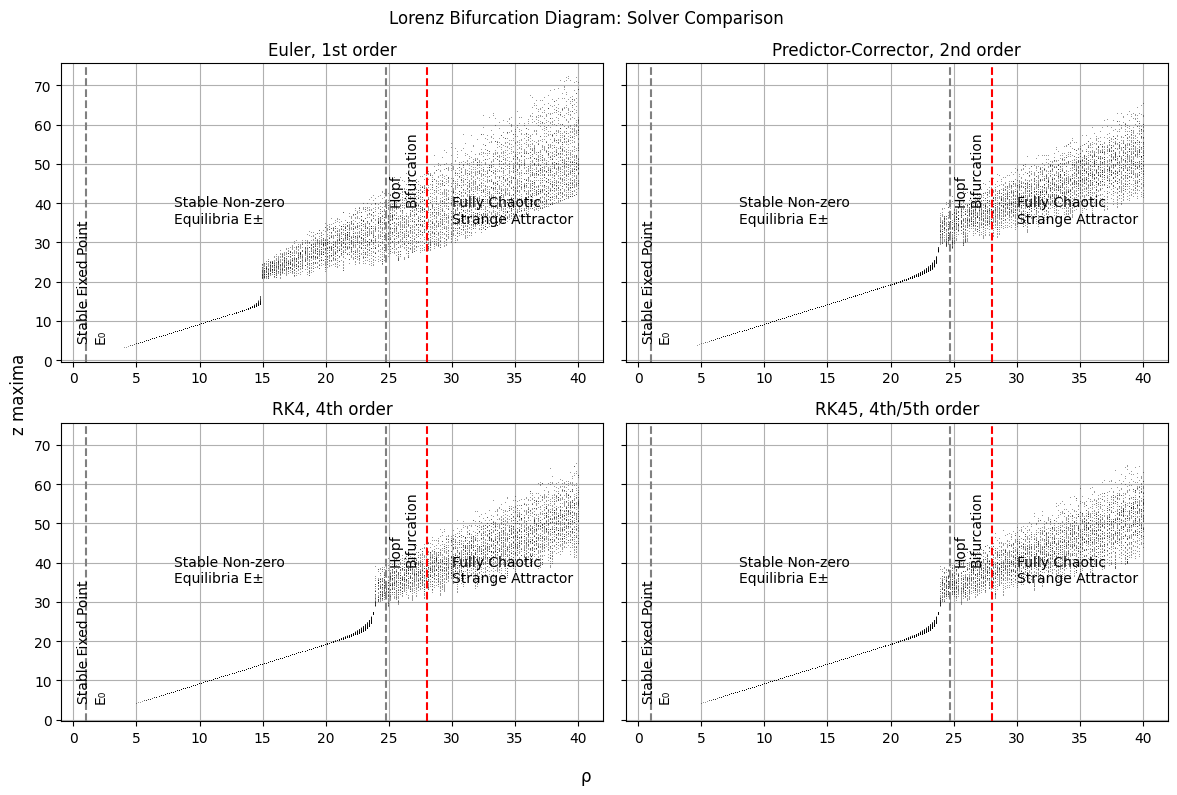

CPU times: user 3min 28s, sys: 227 ms, total: 3min 29s
Wall time: 3min 30s


In [ ]:
## Lorenz comparison
%%time
# Fixed parameters
sigma = 10
beta = 8/3

def lorenz(X, rho):
    x,y,z = X
    return np.array([
        sigma*(y-x),
        x*(rho-z) - y,
        x*y - beta*z
    ])

# time settings
dt = 0.01
tmax = 60
steps = int(tmax/dt)

rho_vals = np.linspace(0,40,250)

# Solvers:

#1) 1st order Euler
def euler_solver(X0,rho):
    X = np.zeros((steps,3))
    X[0] = X0
    for i in range(steps-1):
        X[i+1] = X[i] + dt*lorenz(X[i],rho)
    return X

#2) 2nd order Predictor-Corrector
def heun_solver(X0,rho):
    X = np.zeros((steps,3))
    X[0] = X0
    for i in range(steps-1):
        k1 = lorenz(X[i],rho)
        pred = X[i] + dt*k1
        k2 = lorenz(pred,rho)
        X[i+1] = X[i] + dt*(k1+k2)/2
    return X

#3) 4th order
def rk4_solver(X0,rho):
    X = np.zeros((steps,3))
    X[0] = X0
    for i in range(steps-1):
        k1 = lorenz(X[i],rho)
        k2 = lorenz(X[i] + dt*k1/2,rho)
        k3 = lorenz(X[i] + dt*k2/2,rho)
        k4 = lorenz(X[i] + dt*k3,rho)
        X[i+1] = X[i] + dt*(k1+2*k2+2*k3+k4)/6
    return X

#4) 4th/5th order Scipy
def rk45_solver(X0,rho):
    sol = solve_ivp(
        lambda t,X: lorenz(X,rho),
        [0,tmax],
        X0,
        method='RK45',
        max_step=dt
    )
    return sol.y.T

# bifurcation

def bifurcation(solver):

    rho_plot = []
    z_plot = []

    for rho in rho_vals:

        X = solver([1,1,1],rho)

        z = X[:,2]

        # remove transient
        z = z[len(z)//2:]

        # detect local maxima
        peaks = (z[1:-1] > z[:-2]) & (z[1:-1] > z[2:])
        zmax = z[1:-1][peaks]

        if len(zmax) > 0:
            rho_plot.extend([rho]*len(zmax))
            z_plot.extend(zmax)

    return rho_plot,z_plot

solvers = [
    ("Euler, 1st order", euler_solver),
    ("Predictor-Corrector, 2nd order", heun_solver),
    ("RK4, 4th order", rk4_solver),
    ("RK45, 4th/5th order", rk45_solver)
]

fig,axes = plt.subplots(2,2,figsize=(12,8),sharex=False,sharey=True)
axes = axes.flatten()

for ax,(name,solver) in zip(axes,solvers):

    rho_plot,z_plot = bifurcation(solver)

    ax.plot(rho_plot,z_plot,',k',alpha=0.4)
    ax.set_title(name)
    ax.grid(True)

    ax.axvline(1, linestyle='--',color='gray')
    ax.axvline(24.74, linestyle='--',color='gray')
    ax.axvline(28, linestyle='--', color='red')

    ax.text(0.3, 5, "Stable Fixed Point\nE₀", rotation=90)
    ax.text(8, 35, "Stable Non-zero\nEquilibria E±")
    ax.text(25, 40, "Hopf\nBifurcation", rotation=90)
    ax.text(30, 35, "Fully Chaotic\nStrange Attractor")

fig.supxlabel("ρ")
fig.supylabel("z maxima")
fig.suptitle("Lorenz Bifurcation Diagram: Solver Comparison")

plt.tight_layout()
plt.show()